In [39]:
import numpy as np 
import pandas as pd

In [40]:
# for  i in range(m):
#     z1 = np.dot(W1, x)+ b1
#     a1 = relu(z1)

#     z2 = np.dot(W2, a1)+ b2
#     a2 = relu(z2)

#     z3 = np.dot(W3, a2)+ b3
#     a3 = sigmoid(z3)

In [41]:
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def tanh(Z):
    return np.tanh(Z)

def leaky_relu(Z):
    return np.maximum(0.01*Z, Z)


In [42]:
# Derivatives of the Activation Functions

def relu_derivative(Z):
   return np.where(Z < 0, 0, 1)

def sigmoid_derivative(Z):
    A = sigmoid(Z)
    return A * (1 - A)

def tanh_derivative(Z):
    A = tanh(Z)
    return 1 - A**2

def leaky_relu_derivative(Z):
    return np.where(Z < 0, 0.01, 1)


In [43]:
# Listing 3.3 Loading German Credit Numeric Dataset

import tensorflow_datasets as tfds  

def load_german_credit_numeric_data():
    dataset, metadata = tfds.load("german_credit_numeric", 
                               with_info=True,
                               split="train"   )
    df = tfds.as_dataframe(dataset)
    X = np.stack(df["features"].values)
    y = df["label"].values
    return X, y

X, y = load_german_credit_numeric_data()


In [44]:
# Listing 3.4 Function to Split Dataset into Train and Test Set
from sklearn.model_selection   import train_test_split

def split_dataset(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
                                                        X,
                                                        y, 
                                                        test_size=test_size,
                                                        random_state=random_state
                                                )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_dataset(X, y)

In [45]:
# Listing 3.5 Function to Normalize Input Features
from sklearn.preprocessing import StandardScaler

def normalize_features(X_train, X_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test

X_train, X_test = normalize_features(X_train, X_test)


In [46]:
# a = 1
# L = 100
# w = 1.5

# for l in range(1, L+1):
#     z = w*a
#     a = relu(z)
#     if l%20 == 0:
#         print(f"Layer: {l}, Activation: {a}")

# Layer: 20, Activation: 3325.256730079651
# Layer: 40, Activation: 11057332.320940012
# Layer: 60, Activation: 36768468716.93302
# Layer: 80, Activation: 122264598055704.66
# Layer: 100, Activation: 4.065611775352152e+17

In [47]:
# a = 1
# L = 100
# w = 0.5

# for l in range(1, L+1):
#     z = w*a
#     a = relu(z)
#     if l%20 == 0:
#     print(f"Layer: {l}, Activation: {a}")


# Layer: 20, Activation: 9.5367431640625e-07
# Layer: 40, Activation: 9.094947017729282e-13
# Layer: 60, Activation: 8.673617379884035e-19
# Layer: 80, Activation: 8.271806125530277e-25
# Layer: 100, Activation: 7.888609052210118e-31

In [48]:
def initialize_parameters(layer_dims, initialization="he"):
    np.random.seed(100)
    parameters = {}
    
    L = len(layer_dims) - 1

    for l in range(1, L+1):
 
        if initialization == "he":
            parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2 / layer_dims[l-1])

        elif initialization == "xavier":
            parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(1 / layer_dims[l-1])

        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters


In [49]:
# Listing 3.7 Binary Cross-Entropy Loss Function

def compute_loss(y_hat, y):
    loss = - (y * np.log(y_hat) + (1-y) * np.log(1-y_hat))
    return loss

# Listing 3.8 Computing Binary Cross-Entropy Cost
def compute_cost(Y_hat, Y):
    m = Y.shape[1]
    cost = -(1 / m) * np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
    return cost

In [50]:
[1000] + [3,3] + [1]

[1000, 3, 3, 1]

In [51]:
def train_nonvec(X, y, learning_rate, num_iterations, hidden_layer_sizes):
    X = X.T
    Y = y.reshape(1, -1)
    
    nx, m = X.shape  #  (1000,24)
    layer_sizes = [nx] + hidden_layer_sizes + [1]    # [1000, 3, 3, 1]
    
    parameters = initialize_parameters(layer_sizes)  # 'HE'  initialization
    
    W1 = parameters['W1']
    b1 = parameters['b1']

    W2 = parameters['W2']
    b2 = parameters['b2']
    
    W3 = parameters['W3']
    b3 = parameters['b3']
    
    costs = []  # Hər iterasiyada loss dəyərlərini saxlamaq üçün

    for i_iter in range(num_iterations):  # 2001
        
        J = 0                              # Ümumi loss (cost)
# Gradientlər üçün sıfır matrislər (hər parametr üçün)
        dW1 = np.zeros_like(W1)             # W1 gradienti
        db1 = np.zeros_like(b1)             # b1 gradienti

        dW2 = np.zeros_like(W2)             # W2 gradienti
        db2 = np.zeros_like(b2)             # b2 gradienti
        
        dW3 = np.zeros_like(W3)             # W3 gradienti
        db3 = np.zeros_like(b3)             # b3 gradienti
        
        for i in range(m):

            x = X[:, i][:, None]            # [:, None] ilə vektor formasına salırıq
            y = Y[:, i]                      # Həqiqi etiket
            
            z1 = np.dot(W1, x) + b1
            a1 = relu(z1)

            z2 = np.dot(W2, a1) + b2
            a2 = relu(z2)
            
            z3 = np.dot(W3, a2) + b3
            a3 = sigmoid(z3)
            
            loss = compute_loss(a3, y)
            J += loss          

            dz3 = a3 - y            # ∂L/∂z3 = (∂L/∂a3) · (∂a3/∂z3)
            dW3 += np.dot(dz3, a2.T)  
            db3 += dz3
            da2 = np.dot(W3.T, dz3)
            dz2 = da2 * relu_derivative(z2)            
            dW2 += np.dot(dz2, a1.T)            
            db2 += dz2               
            da1 = np.dot(W2.T, dz2)            
            dz1 = da1 * relu_derivative(z1)            
            dW1 += np.dot(dz1, x.T)            
            db1 += dz1
        
        J /= m
    
        dW1 /= m
        dW2 /= m
        dW3 /= m
        db1 /= m
        db2 /= m
        db3 /= m
        

        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1
        
        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2
        
        W3 = W3 - learning_rate * dW3
        b3 = b3 - learning_rate * db3
        

        costs.append(np.squeeze(J))
        
        if i_iter % 500 == 0:
            print(f"Iteration: {i_iter}, Cost: {np.squeeze(J)}")
    

    parameters = {
        "W1": W1,  # 1-ci gizli qatın çəkiləri
        "b1": b1,  # 1-ci gizli qatın bias-ı
        "W2": W2,  # 2-ci gizli qatın çəkiləri
        "b2": b2,  # 2-ci gizli qatın bias-ı
        "W3": W3,  # Çıxış qatının çəkiləri
        "b3": b3   # Çıxış qatının bias-ı
    }
    
    return parameters, costs

In [52]:
num_iterations = 2001
learning_rate = 0.01
hidden_layer_sizes = [3, 3]
parameters_nonvec, costs = train_nonvec(X_train,
                                        y_train,
                                        learning_rate,
                                        num_iterations,
                                        hidden_layer_sizes)


Iteration: 0, Cost: 0.858503542667785


KeyboardInterrupt: 

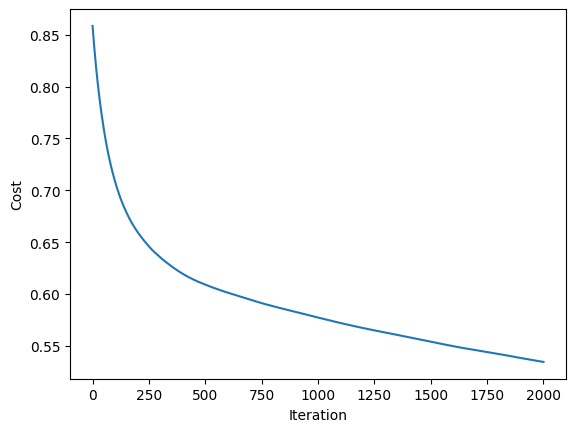

In [ ]:
import matplotlib.pyplot as plt  # DÜZGÜN!

# İndi plt.figure() işləyəcək
def plot_costs(costs):
    plt.figure()
    plt.plot(costs)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    return None

plot_costs(costs)

####  Vectorized 

In [ ]:
import numpy as np

def forward_propagation(X, parameters):

    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']
    W3 = parameters['W3']
    b3 = parameters['b3']

    # Layer 1
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # Layer 2
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    # Output Layer
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    cache = (
        X, Z1, A1, W1, b1,
        Z2, A2, W2, b2,
        Z3, A3, W3, b3
    )

    return A3, cache



def backward_propagation(A3, Y, cache):

    m = Y.shape[1]

    (X, Z1, A1, W1, b1,
     Z2, A2, W2, b2,
     Z3, A3, W3, b3) = cache

    # Output layer gradients
    dZ3 = A3 - Y
    dW3 = (1. / m) * np.dot(dZ3, A2.T)
    db3 = (1. / m) * np.sum(dZ3, axis=1, keepdims=True)

    # Layer 2 gradients
    dA2 = np.dot(W3.T, dZ3)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (1. / m) * np.dot(dZ2, A1.T)
    db2 = (1. / m) * np.sum(dZ2, axis=1, keepdims=True)

    # Layer 1 gradients
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (1. / m) * np.dot(dZ1, X.T)
    db1 = (1. / m) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {
        "dZ3": dZ3, "dW3": dW3, "db3": db3,
        "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,
        "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1
    }

    return grads



def update_parameters(parameters, grads, learning_rate):

    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']
    W3 = parameters['W3']
    b3 = parameters['b3']

    dW1 = grads['dW1']
    db1 = grads['db1']
    dW2 = grads['dW2']
    db2 = grads['db2']
    dW3 = grads['dW3']
    db3 = grads['db3']

    # Gradient Descent update
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3

    parameters = {
        "W1": W1, "b1": b1,
        "W2": W2, "b2": b2,
        "W3": W3, "b3": b3
    }

    return parameters


def train_vec(X, y, learning_rate, num_iterations, hidden_layer_sizes):

    X = X.T
    Y = y.reshape(1, -1)

    nx, m = X.shape

    # layer structure
    layer_sizes = [nx] + hidden_layer_sizes + [1]

    parameters = initialize_parameters(layer_sizes)

    costs = []

    for i_iter in range(num_iterations):

        # Forward pass
        A3, cache = forward_propagation(X, parameters)

        # Cost
        cost = compute_cost(A3, Y)

        # Backward pass
        grads = backward_propagation(A3, Y, cache)

        # Update
        parameters = update_parameters(
            parameters,
            grads,
            learning_rate
        )

        costs.append(np.squeeze(cost))

        if i_iter % 500 == 0:
            print(f"Iteration: {i_iter}, Cost: {np.squeeze(cost)}")

    return parameters, costs

In [ ]:
num_iterations = 2000
learning_rate = 0.01
hidden_layer_sizes = [3, 3]
parameters_vec, costs = train_vec(X_train, y_train, learning_rate,num_iterations, hidden_layer_sizes)

Iteration: 0, Cost: 0.8585035426677877
Iteration: 500, Cost: 0.6090345983533605
Iteration: 1000, Cost: 0.5773339483747065
Iteration: 1500, Cost: 0.5540681678187224


###  Non  Vectorized Prediction


In [53]:
# Listing 3.15 — Non-vectorized Prediction

def predict_nonvec(X, parameters):

    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']
    W3 = parameters['W3']
    b3 = parameters['b3']

    X = X.T
    nx, m = X.shape

    y_hat = []

    for i in range(m):
        x = X[:, i][:, None]

        z1 = np.dot(W1, x) + b1
        a1 = relu(z1)

        z2 = np.dot(W2, a1) + b2
        a2 = relu(z2)

        z3 = np.dot(W3, a2) + b3
        a3 = sigmoid(z3)

        y_hat.append(float(np.squeeze(a3)))

    return np.array(y_hat)

In [54]:
# Prediction execution (non-vectorized)

y_hat = predict_nonvec(X_test, parameters_nonvec)
y_pred = (y_hat > 0.5).astype(int)

In [55]:
# Listing 3.16 — Classification Metrics

from sklearn.metrics import f1_score, precision_score, recall_score

def classification_metrics(y_test, y_pred):

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f'F1 Score: {f1}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')

    return precision, recall, f1


# Metrics calculation

precision, recall, f1 = classification_metrics(y_test, y_pred)

F1 Score: 0.83125
Precision: 0.7388888888888889
Recall: 0.95


### Vectorized prediction


In [56]:
# Listing 3.17 — Vectorized Prediction

def predict_vec(X, parameters):

    X = X.T

    y_hat, _ = forward_propagation(X, parameters)
    y_hat = np.squeeze(y_hat)

    return y_hat


# Prediction execution (vectorized)

y_hat = predict_vec(X_test, parameters_vec)
y_pred = (y_hat > 0.5).astype(int)

precision, recall, f1 = classification_metrics(y_test, y_pred)

F1 Score: 0.83125
Precision: 0.7388888888888889
Recall: 0.95
